## Aggregation

In [368]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('data/nba_players.csv')
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,1,Tyrese Maxey,25,PHI,PG,61,61,2334,616,1336,...,251,407,124,50,149,132,1767,0,AS,maxeyty01
1,2,Luka Dončić,26,LAL,PG,52,52,1846,542,1144,...,406,437,77,27,210,125,1692,6,AS,doncilu01
2,3,Shai Gilgeous-Alexander,27,OKC,PG,53,53,1770,573,1044,...,233,341,72,41,114,107,1677,0,AS,gilgesh01
3,4,Jaylen Brown,29,BOS,SF,57,57,1955,602,1254,...,412,291,56,24,204,155,1635,3,AS,brownja02
4,5,Donovan Mitchell,29,CLE,SG,56,56,1874,555,1149,...,254,325,87,17,170,133,1600,0,AS,mitchdo01


In [369]:
df.columns

Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Trp-Dbl', 'Awards', 'Player-additional'],
      dtype='object')

In [370]:
df['PPG'] = df['PTS']/df['G']
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,PPG
0,1,Tyrese Maxey,25,PHI,PG,61,61,2334,616,1336,...,407,124,50,149,132,1767,0,AS,maxeyty01,28.967213
1,2,Luka Dončić,26,LAL,PG,52,52,1846,542,1144,...,437,77,27,210,125,1692,6,AS,doncilu01,32.538462
2,3,Shai Gilgeous-Alexander,27,OKC,PG,53,53,1770,573,1044,...,341,72,41,114,107,1677,0,AS,gilgesh01,31.641509
3,4,Jaylen Brown,29,BOS,SF,57,57,1955,602,1254,...,291,56,24,204,155,1635,3,AS,brownja02,28.684211
4,5,Donovan Mitchell,29,CLE,SG,56,56,1874,555,1149,...,325,87,17,170,133,1600,0,AS,mitchdo01,28.571429


In [371]:
df['Team'].unique()
f = df['Team'].isin(['2TM', '3TM'])
df = df[~f]
df['Team'].unique()

array(['PHI', 'LAL', 'OKC', 'BOS', 'CLE', 'MIN', 'NYK', 'HOU', 'DEN',
       'DET', 'LAC', 'TOR', 'IND', 'ATL', 'ORL', 'NOP', 'UTA', 'BRK',
       'CHO', 'SAS', 'PHO', 'POR', 'SAC', 'MIA', 'WAS', 'GSW', 'DAL',
       'MIL', 'CHI', 'MEM'], dtype=object)

## get average

In [372]:
# get average points per game for all players
average_points_all = df['PPG'].mean()
average_points_all

np.float64(8.767357964580084)

In [373]:
# filter for BOS
bos_players = df[df['Team'] == 'BOS'].sort_values(by='PPG', ascending=False)
bos_players.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,PPG
3,4,Jaylen Brown,29,BOS,SF,57,57,1955,602,1254,...,291,56,24,204,155,1635,3,AS,brownja02,28.684211
572,451,Jayson Tatum,27,BOS,PF,2,2,54,12,32,...,9,1,0,3,3,35,0,NaN,tatumja01,17.500000
40,37,Derrick White,31,BOS,SG,62,62,2123,368,939,...,353,73,90,109,94,1066,0,NaN,whitede01,17.193548
41,38,Payton Pritchard,28,BOS,PG,63,48,2047,401,869,...,338,48,7,83,89,1063,0,NaN,pritcpa01,16.873016
100,88,Anfernee Simons,26,BOS,SG,49,0,1202,250,568,...,116,27,6,55,82,694,0,NaN,simonan01,14.163265


<Axes: xlabel='Team', ylabel='PPG'>

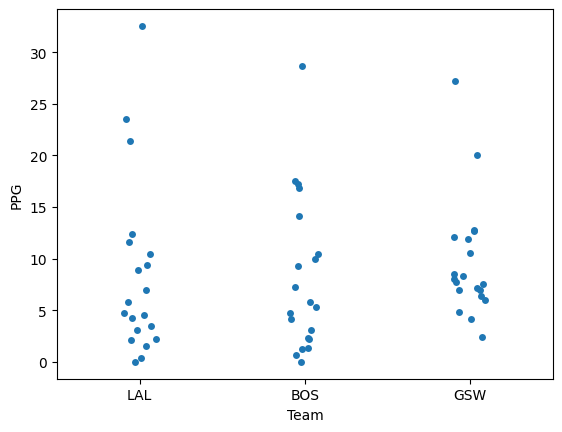

In [374]:
teams = ['BOS', 'LAL', 'GSW']
f = df['Team'].isin(teams)
sns.stripplot(data=df[f], x='Team', y='PPG')



## using groupby

In [375]:
# use groupby to get average points per game by team
average_points_by_team = df.groupby('Team')['PPG'].mean()
average_points_by_team.sort_values(ascending=False).head()

Team
UTA    10.219295
POR     9.790571
MEM     9.738897
GSW     9.612728
MIA     9.586156
Name: PPG, dtype: float64

### get the total percent of points scored by the top 5 players for each team

In [376]:
df.groupby('Team')['PTS']

In [377]:
# pts scored by top 5 scorers for each team
top_5_points_by_team = df.groupby('Team')['PTS'].nlargest(5)#.sum(level=0)

# sum of points scored by top 5 scorers for each team
top_5_points_by_team_sum = top_5_points_by_team.groupby(level=0).sum()
top_5_points_by_team_sum.sort_values(ascending=False).head()

Team
MIN    5574
HOU    5541
NYK    5232
BOS    5055
NOP    4983
Name: PTS, dtype: int64

In [378]:
total_points_by_team = df.groupby('Team')['PTS'].sum()
total_points_by_team.head()

Team
ATL    7534
BOS    7325
BRK    6732
CHI    7387
CHO    7533
Name: PTS, dtype: int64

In [379]:

percent_top_5_by_team = (top_5_points_by_team_sum / total_points_by_team) * 100
percent_top_5_by_team.sort_values(ascending=False).head()


Team
HOU    76.745152
MIN    73.429061
BOS    69.010239
NYK    68.842105
TOR    68.458531
Name: PTS, dtype: float64

<Axes: xlabel='Team'>

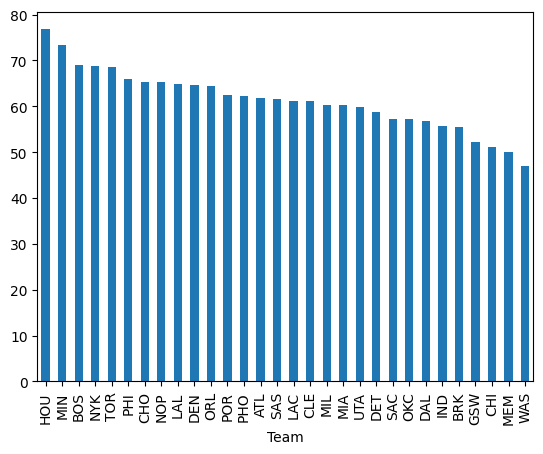

In [380]:
percent_top_5_by_team.sort_values(ascending=False).plot.bar()